# **Pertanyaan Analisis Data**



*   Acara apa yang rentan terjadi food wastage?
*   Apakah cara penyimpanan makanan mempengaruhi jumlah food wastage?
* Sebutkan 3 tipe makanan yang memiliki nilai food wastage tertinggi!



# **Import Library yang akan digunakan**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Wrangling**



> **Gathering Data**



In [ ]:
data = pd.read_csv('https://drive.google.com/uc?id=1wxbBi5KBPFfdxvMf-GiUt3NdduSSVmjG')
data.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25




> **Assessing Data**



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB




> **Cleaning Data**



In [ ]:
data = data.drop(['Geographical Location', 'Purchase History', 'Pricing'], axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Type of Food         1782 non-null   object
 1   Number of Guests     1782 non-null   int64 
 2   Event Type           1782 non-null   object
 3   Quantity of Food     1782 non-null   int64 
 4   Storage Conditions   1782 non-null   object
 5   Seasonality          1782 non-null   object
 6   Preparation Method   1782 non-null   object
 7   Wastage Food Amount  1782 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 111.5+ KB


In [ ]:
# Mengubah tipe data

change_data = 'Number of Guests'

data[change_data] = data[change_data].astype(str)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Type of Food         1782 non-null   object
 1   Number of Guests     1782 non-null   object
 2   Event Type           1782 non-null   object
 3   Quantity of Food     1782 non-null   int64 
 4   Storage Conditions   1782 non-null   object
 5   Seasonality          1782 non-null   object
 6   Preparation Method   1782 non-null   object
 7   Wastage Food Amount  1782 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 111.5+ KB


In [ ]:
# Menyimpan Data

data.to_csv('food_wastage.csv', index=False)

In [ ]:
data = pd.read_csv('food_wastage.csv')
print(data.shape)
print(data.columns.tolist())
data.head()

(1782, 8)
['Type of Food', 'Number of Guests', 'Event Type', 'Quantity of Food', 'Storage Conditions', 'Seasonality', 'Preparation Method', 'Wastage Food Amount']


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,All Seasons,Buffet,25
1,Meat,400,Birthday,500,Room Temperature,Winter,Buffet,40
2,Vegetables,302,Birthday,371,Refrigerated,Summer,Buffet,27
3,Meat,491,Birthday,497,Refrigerated,All Seasons,Finger Food,32
4,Meat,300,Corporate,400,Refrigerated,Winter,Finger Food,25


# **Exploratory Data Analisis (EDA)**






In [ ]:
# EDA 1: Statistik Deskriptif
data.describe(include='all')

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Seasonality,Preparation Method,Wastage Food Amount
count,1782,1782.000000,1782,1782.000000,1782,1782,1782,1782.000000
unique,5,NaN,4,NaN,2,3,3,NaN
top,Meat,NaN,Corporate,NaN,Room Temperature,Winter,Sit-down Dinner,NaN
freq,437,NaN,515,NaN,1157,632,781,NaN
mean,NaN,317.804714,NaN,411.125701,NaN,NaN,NaN,28.536476
std,NaN,67.829658,NaN,65.204674,NaN,NaN,NaN,10.461317
min,NaN,207.000000,NaN,280.000000,NaN,NaN,NaN,10.000000
25%,NaN,267.000000,NaN,350.000000,NaN,NaN,NaN,20.000000
50%,NaN,302.000000,NaN,400.000000,NaN,NaN,NaN,26.500000
75%,NaN,350.000000,NaN,480.000000,NaN,NaN,NaN,35.000000


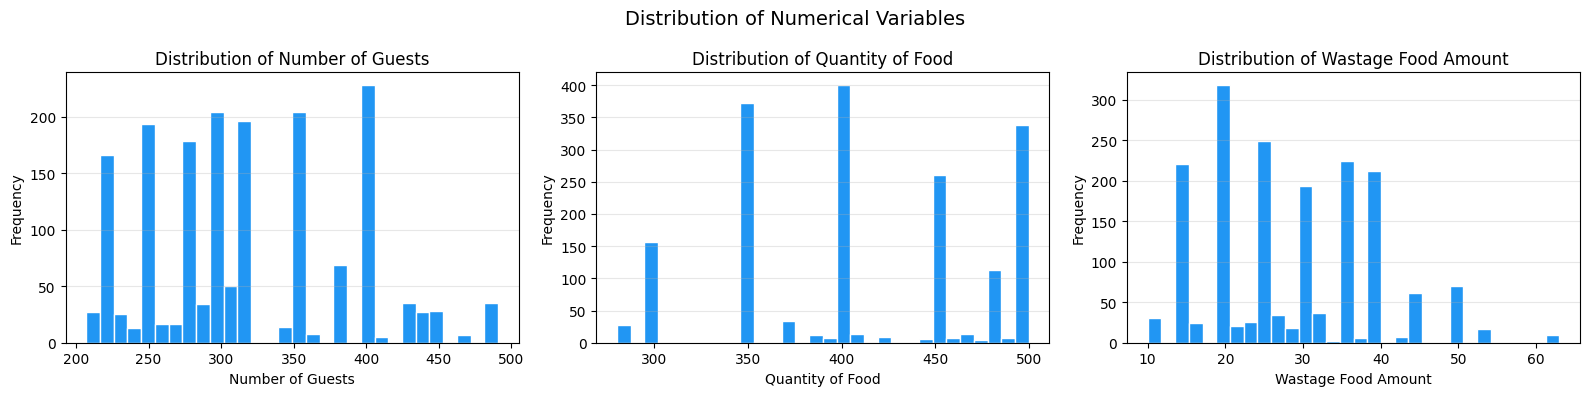

In [ ]:
# EDA 2: Distribusi variabel numerikal
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['Number of Guests', 'Quantity of Food', 'Wastage Food Amount']):
    axes[i].hist(data[col], bins=30, color='#2196F3', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()

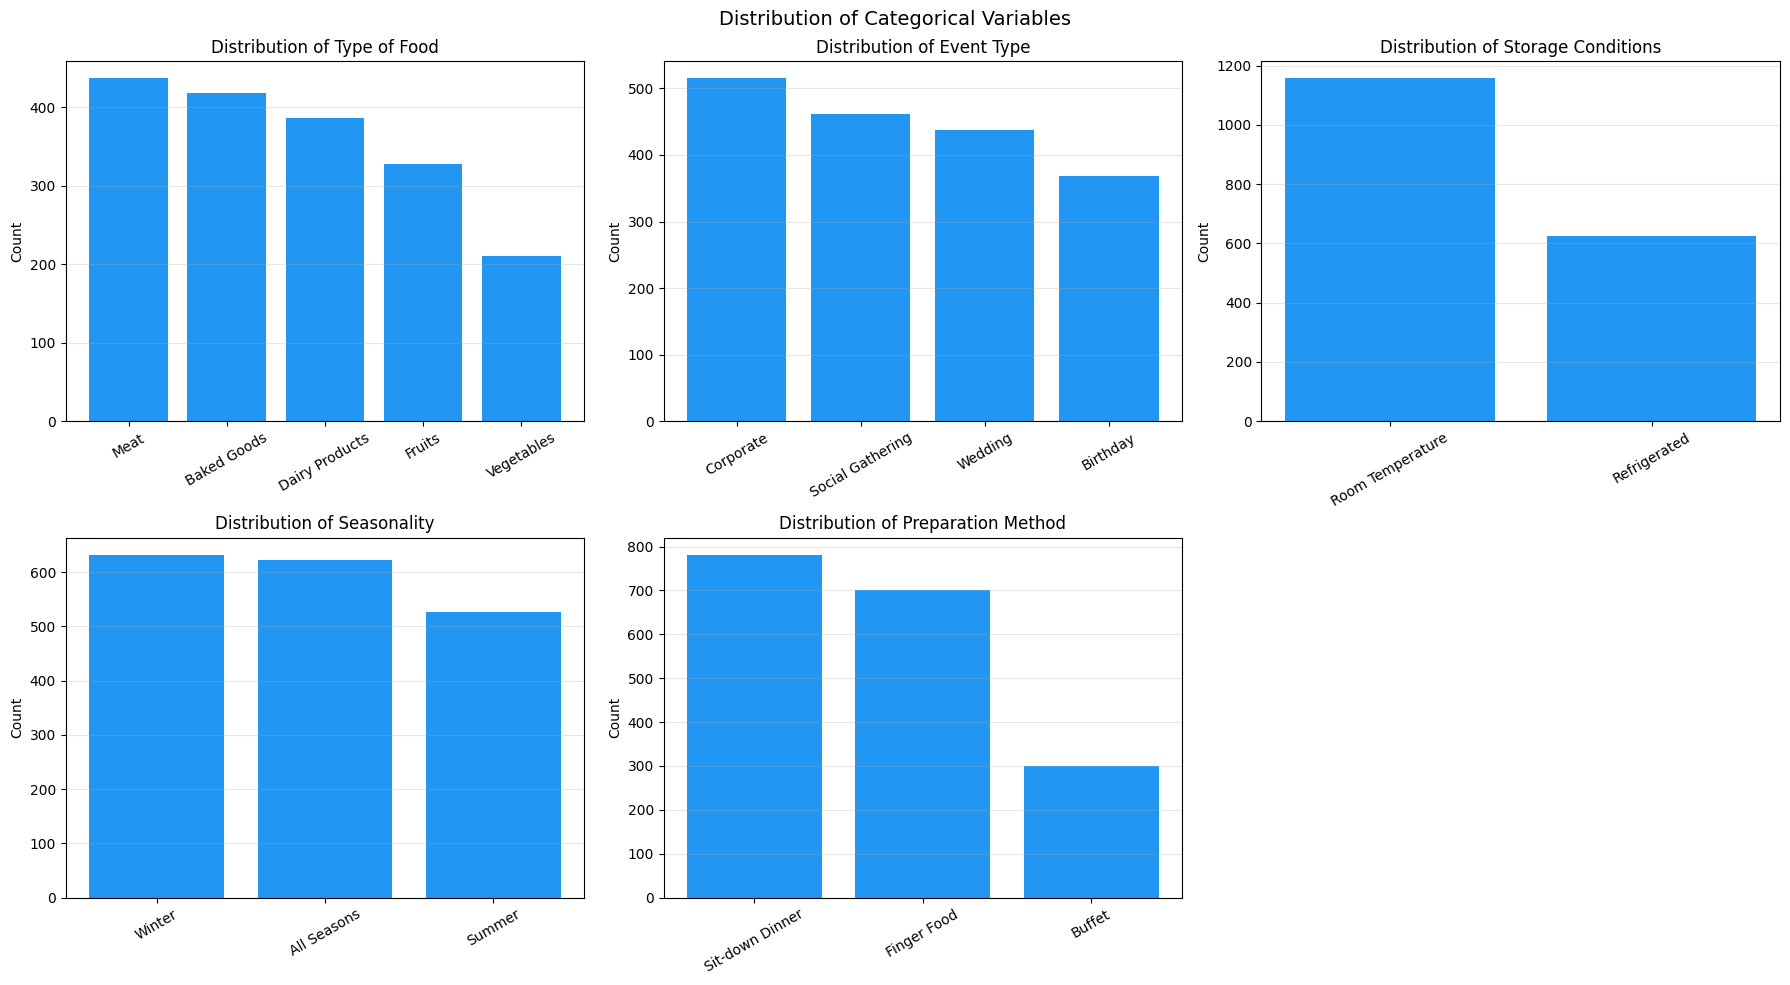

In [ ]:
# EDA 3: Distribusi kategorikal
cat_cols = ['Type of Food', 'Event Type', 'Storage Conditions', 'Seasonality', 'Preparation Method']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = data[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='#2196F3')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle('Distribution of Categorical Variables', fontsize=14)
plt.tight_layout()
plt.show()

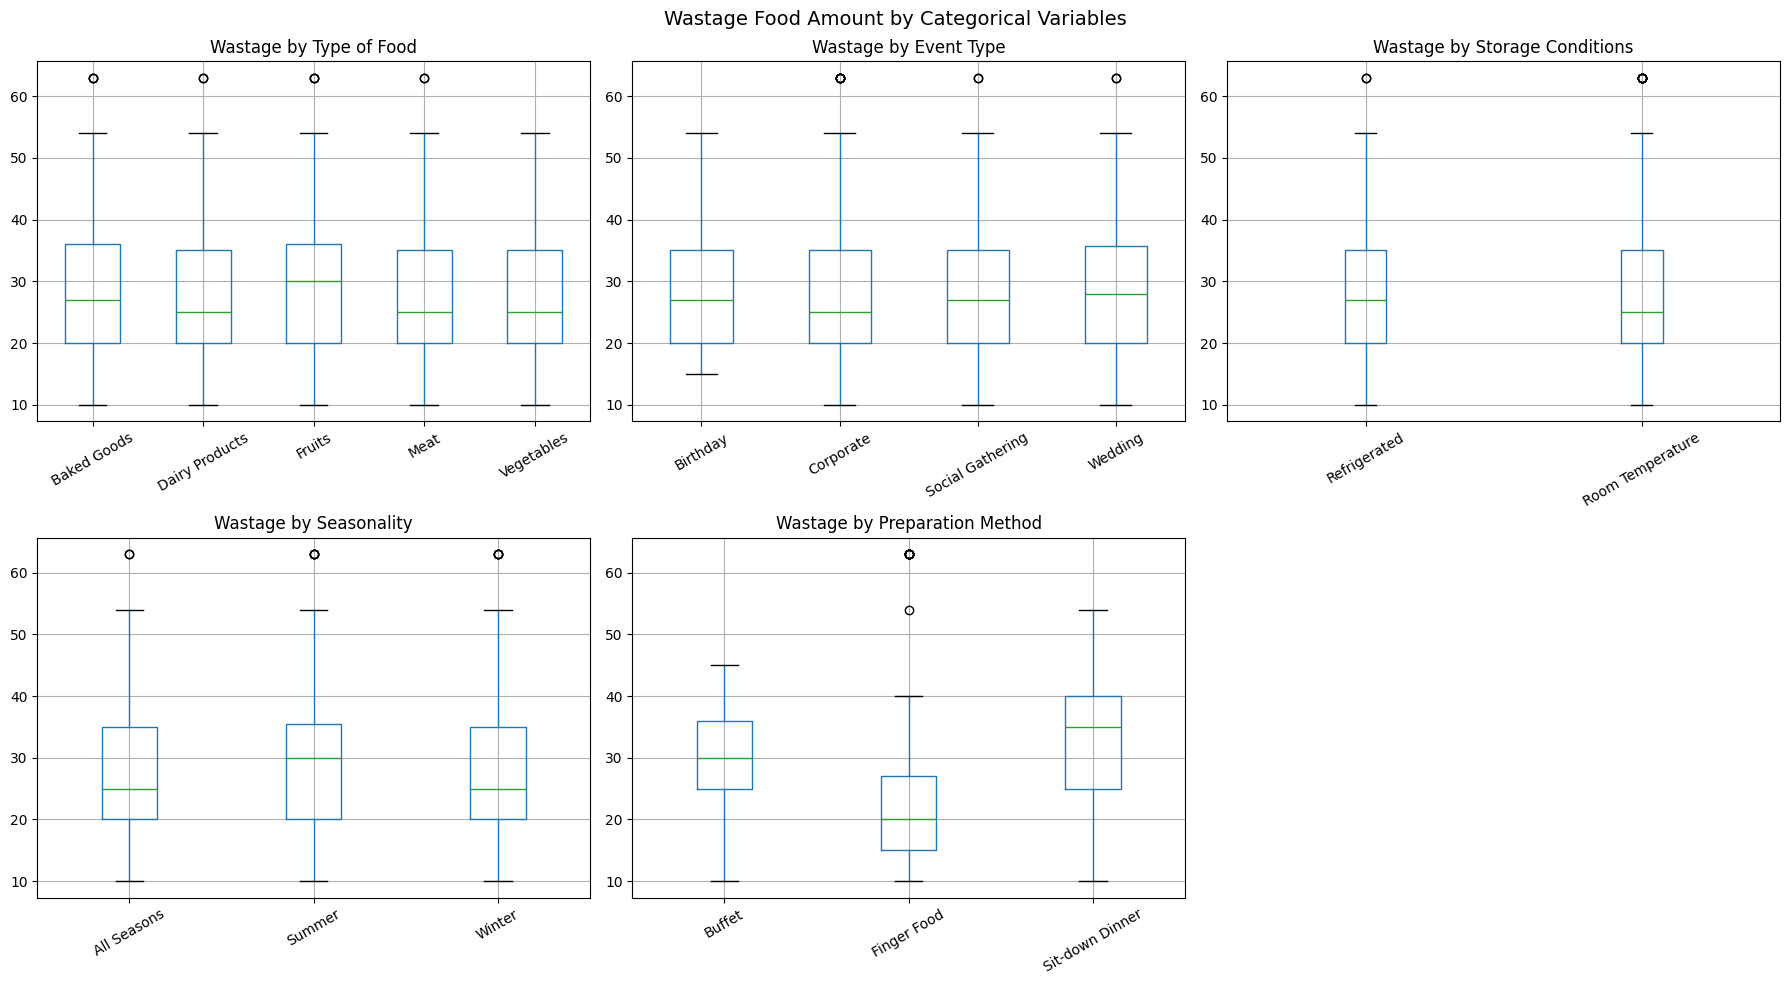

In [ ]:

# EDA 4: Boxplot Wastage per kategori
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    data.boxplot(column='Wastage Food Amount', by=col, ax=axes[i])
    axes[i].set_title(f'Wastage by {col}')
    axes[i].set_xlabel(None)
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[5])
plt.suptitle('Wastage Food Amount by Categorical Variables', fontsize=14)
plt.tight_layout()
plt.show()

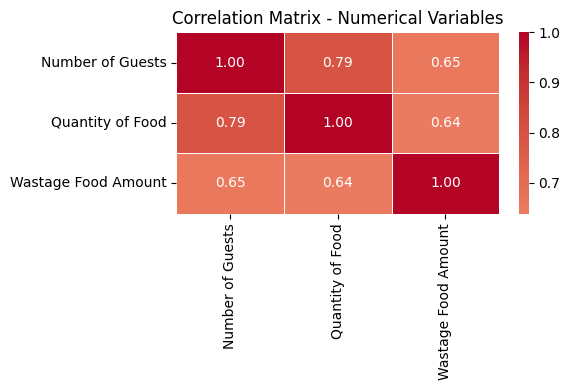

In [ ]:
# EDA 5: Korelasi
corr = data[['Number of Guests', 'Quantity of Food', 'Wastage Food Amount']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

In [ ]:
# EDA 6: Agregasi per kategori
for col in cat_cols:
    print(f"\n--- Wastage by {col} ---")
    print(data.groupby(col)['Wastage Food Amount'].agg(['mean', 'median', 'std', 'min', 'max']).round(2))


--- Wastage by Type of Food ---
                 mean  median    std  min  max
Type of Food                                  
Baked Goods     28.81    27.0  10.70   10   63
Dairy Products  27.85    25.0  10.40   10   63
Fruits          29.47    30.0  10.97   10   63
Meat            28.70    25.0  10.41   10   63
Vegetables      27.46    25.0   9.23   10   54

--- Wastage by Event Type ---
                   mean  median    std  min  max
Event Type                                      
Birthday          28.15    27.0   9.48   15   54
Corporate         28.47    25.0  11.29   10   63
Social Gathering  28.29    27.0  10.14   10   63
Wedding           29.20    28.0  10.58   10   63

--- Wastage by Storage Conditions ---
                     mean  median    std  min  max
Storage Conditions                                
Refrigerated        28.96    27.0  10.18   10   63
Room Temperature    28.31    25.0  10.60   10   63

--- Wastage by Seasonality ---
              mean  median    std  min

# **Visualisasi Data**




## Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| Type of Food | Kategorikal | Jenis makanan yang disajikan |
| Number of Guests | Numerikal | Jumlah tamu yang hadir dalam acara |
| Event Type | Kategorikal | Jenis acara yang diselenggarakan |
| Quantity of Food | Numerikal | Jumlah porsi makanan yang disiapkan |
| Storage Conditions | Kategorikal | Cara penyimpanan makanan sebelum disajikan |
| Seasonality | Kategorikal | Musim saat acara berlangsung |
| Preparation Method | Kategorikal | Metode penyajian makanan |
| Wastage Food Amount | Numerikal | Jumlah makanan yang terbuang (dalam satuan unit) |

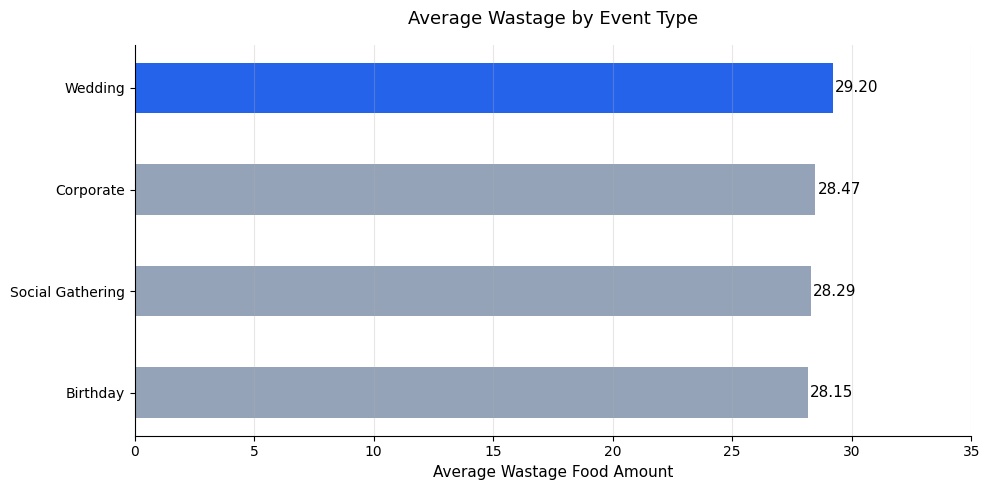

In [ ]:
event_waste = data.groupby('Event Type')['Wastage Food Amount'].mean().sort_values(ascending=True).reset_index()
colors1 = ['#2563EB' if i == len(event_waste)-1 else '#94A3B8' for i in range(len(event_waste))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(event_waste['Event Type'], event_waste['Wastage Food Amount'], color=colors1, height=0.5)
for bar, val in zip(bars, event_waste['Wastage Food Amount']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11)
ax.set_xlim(0, 35)
ax.set_title('Average Wastage by Event Type', fontsize=13, pad=15)
ax.set_xlabel('Average Wastage Food Amount', fontsize=11)
ax.set_ylabel(None)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

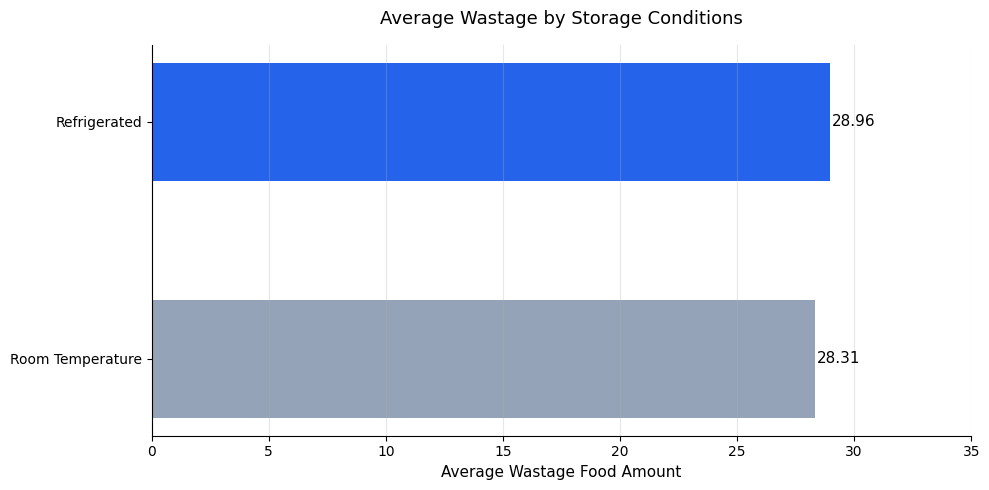

In [ ]:
storage_waste = data.groupby('Storage Conditions')['Wastage Food Amount'].mean().sort_values(ascending=True).reset_index()
colors2 = ['#2563EB' if i == len(storage_waste)-1 else '#94A3B8' for i in range(len(storage_waste))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(storage_waste['Storage Conditions'], storage_waste['Wastage Food Amount'], color=colors2, height=0.5)
for bar, val in zip(bars, storage_waste['Wastage Food Amount']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11)
ax.set_xlim(0, 35)
ax.set_title('Average Wastage by Storage Conditions', fontsize=13, pad=15)
ax.set_xlabel('Average Wastage Food Amount', fontsize=11)
ax.set_ylabel(None)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

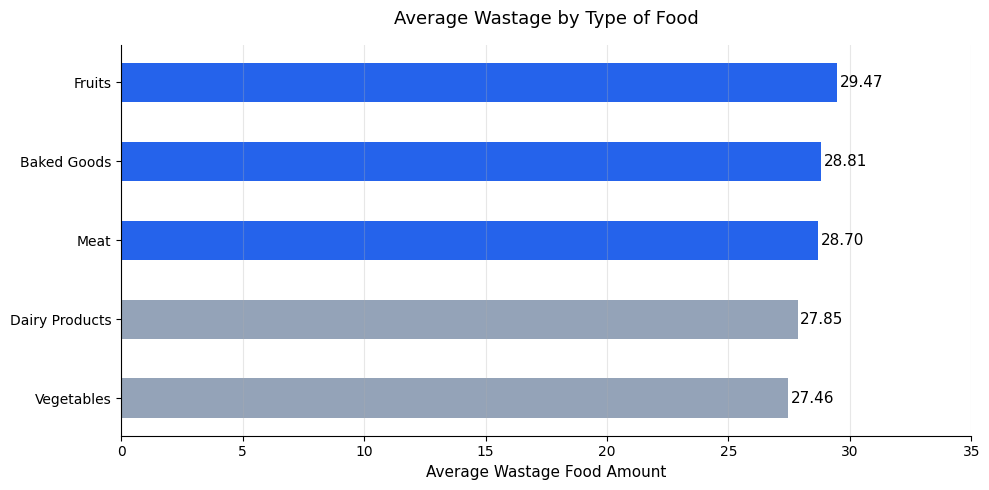

In [ ]:
food_waste = data.groupby('Type of Food')['Wastage Food Amount'].mean().sort_values(ascending=True).reset_index()
colors3 = ['#2563EB' if i >= len(food_waste)-3 else '#94A3B8' for i in range(len(food_waste))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(food_waste['Type of Food'], food_waste['Wastage Food Amount'], color=colors3, height=0.5)
for bar, val in zip(bars, food_waste['Wastage Food Amount']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11)
ax.set_xlim(0, 35)
ax.set_title('Average Wastage by Type of Food', fontsize=13, pad=15)
ax.set_xlabel('Average Wastage Food Amount', fontsize=11)
ax.set_ylabel(None)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Kesimpulan dan Rekomendasi

### Kesimpulan
1.
### Rekomendasi
1.